In [ ]:
%pip install -q xgboost lightgbm

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, ConfusionMatrixDisplay)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [ ]:
if os.path.exists('test.csv'):
    file_path = 'test.csv'
else:
    from google.colab import files
    uploaded = files.upload()
    file_path = list(uploaded.keys())[0]

df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,3,4,3,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0,20.0,satisfied


In [ ]:
print('Shape:', df.shape)
print()
print('Column names:')
print(list(df.columns))

Shape: (25976, 25)

Column names:
['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


In [ ]:
df.dtypes.to_frame('Data Type')

,Data Type
Unnamed: 0,int64
id,int64
Gender,object
Customer Type,object
Age,int64
Type of Travel,object
Class,object
Flight Distance,int64
Inflight wifi service,int64
Departure/Arrival time convenient,int64


In [ ]:
df.isnull().sum()[df.isnull().sum() > 0].to_frame('Missing Values')

,Missing Values
Arrival Delay in Minutes,83


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,25976.0,12987.500000,7498.769632,0.0,6493.75,12987.5,19481.25,25975.0
id,25976.0,65005.657992,37611.526647,17.0,32170.50,65319.5,97584.25,129877.0
Age,25976.0,39.620958,15.135685,7.0,27.00,40.0,51.00,85.0
Flight Distance,25976.0,1193.788459,998.683999,31.0,414.00,849.0,1744.00,4983.0
Inflight wifi service,25976.0,2.724746,1.335384,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,25976.0,3.046812,1.533371,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,25976.0,2.756775,1.412951,0.0,2.00,3.0,4.00,5.0
Gate location,25976.0,2.977094,1.282133,1.0,2.00,3.0,4.00,5.0
Food and drink,25976.0,3.215353,1.331506,0.0,2.00,3.0,4.00,5.0
Online boarding,25976.0,3.261665,1.355536,0.0,2.00,4.0,4.00,5.0


In [ ]:
df.select_dtypes(exclude='number').describe().T

,count,unique,top,freq
Gender,25976,2,Female,13172
Customer Type,25976,2,Loyal Customer,21177
Type of Travel,25976,2,Business travel,18038
Class,25976,3,Business,12495
satisfaction,25976,2,neutral or dissatisfied,14573


**Exploratory Data Analysis**

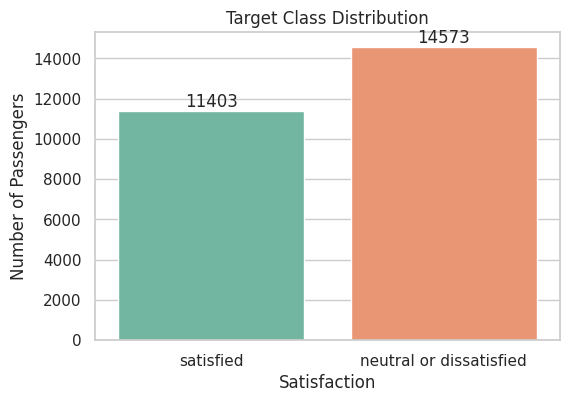

satisfaction
neutral or dissatisfied    0.561
satisfied                  0.439
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='satisfaction', hue='satisfaction', palette='Set2', legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Target Class Distribution')
plt.xlabel('Satisfaction')
plt.ylabel('Number of Passengers')
plt.show()

print(df['satisfaction'].value_counts(normalize=True).round(4))

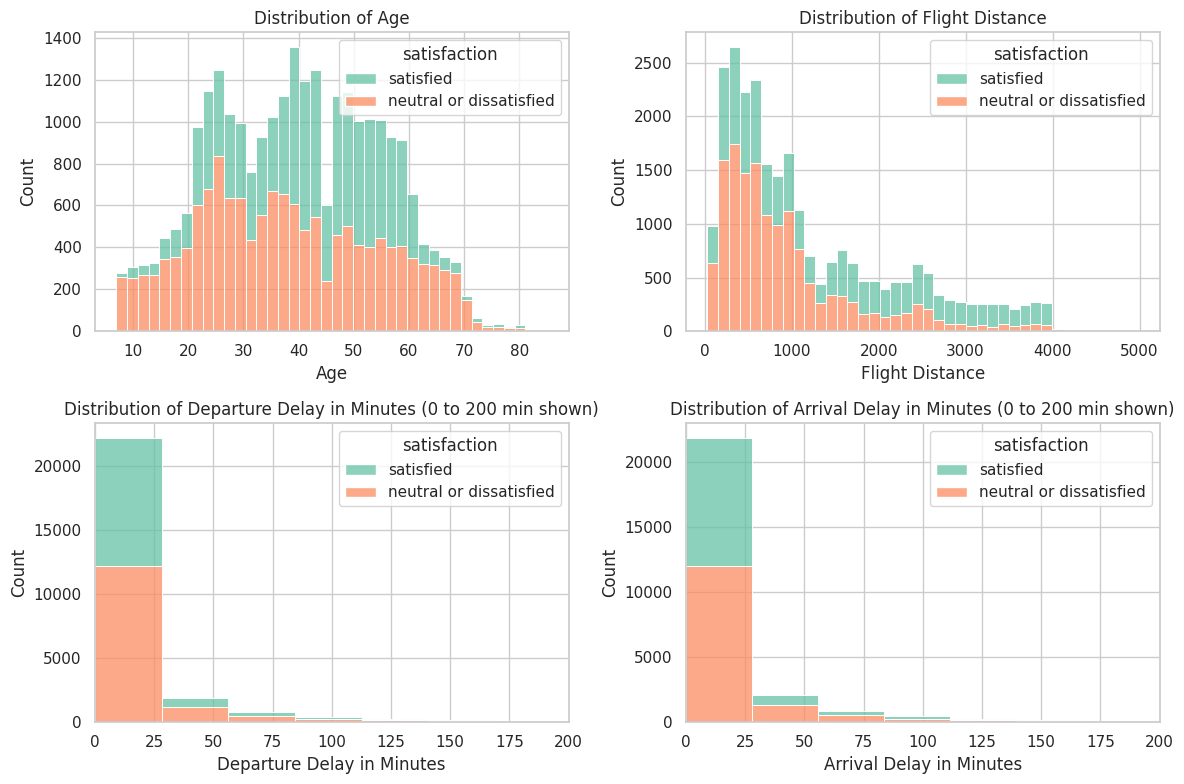

In [ ]:
numeric_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(data=df, x=col, hue='satisfaction', bins=40, multiple='stack', ax=ax, palette='Set2')
    ax.set_title('Distribution of ' + col)
    if 'Delay' in col:
        ax.set_xlim(0, 200)
        ax.set_title('Distribution of ' + col + ' (0 to 200 min shown)')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

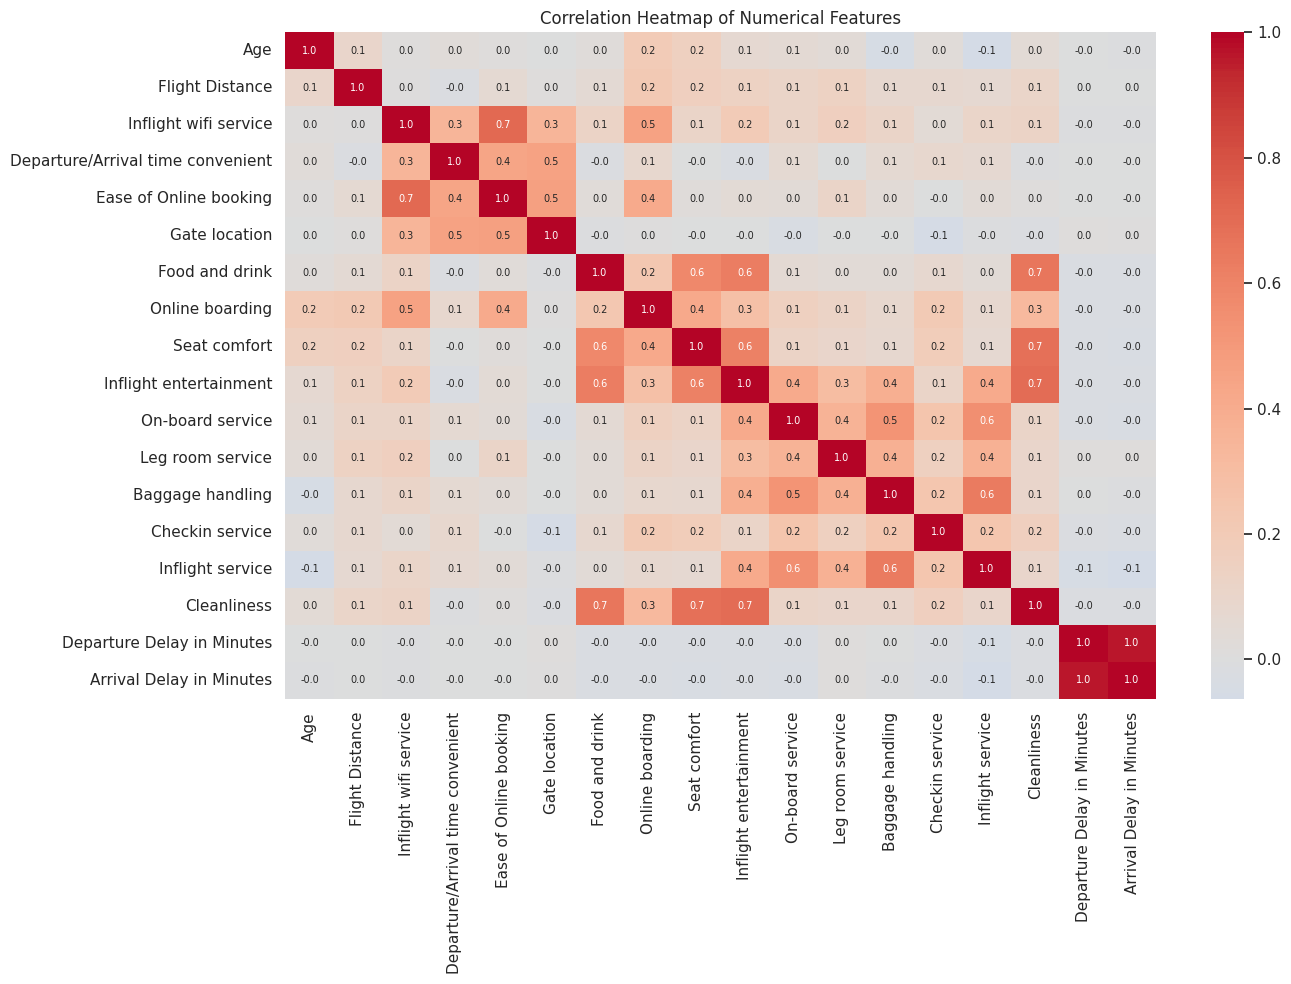

In [ ]:
corr_cols = df.drop(columns=['Unnamed: 0', 'id']).select_dtypes(include='number')

plt.figure(figsize=(14, 10))
sns.heatmap(corr_cols.corr(), annot=True, fmt='.1f', annot_kws={'size': 7}, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

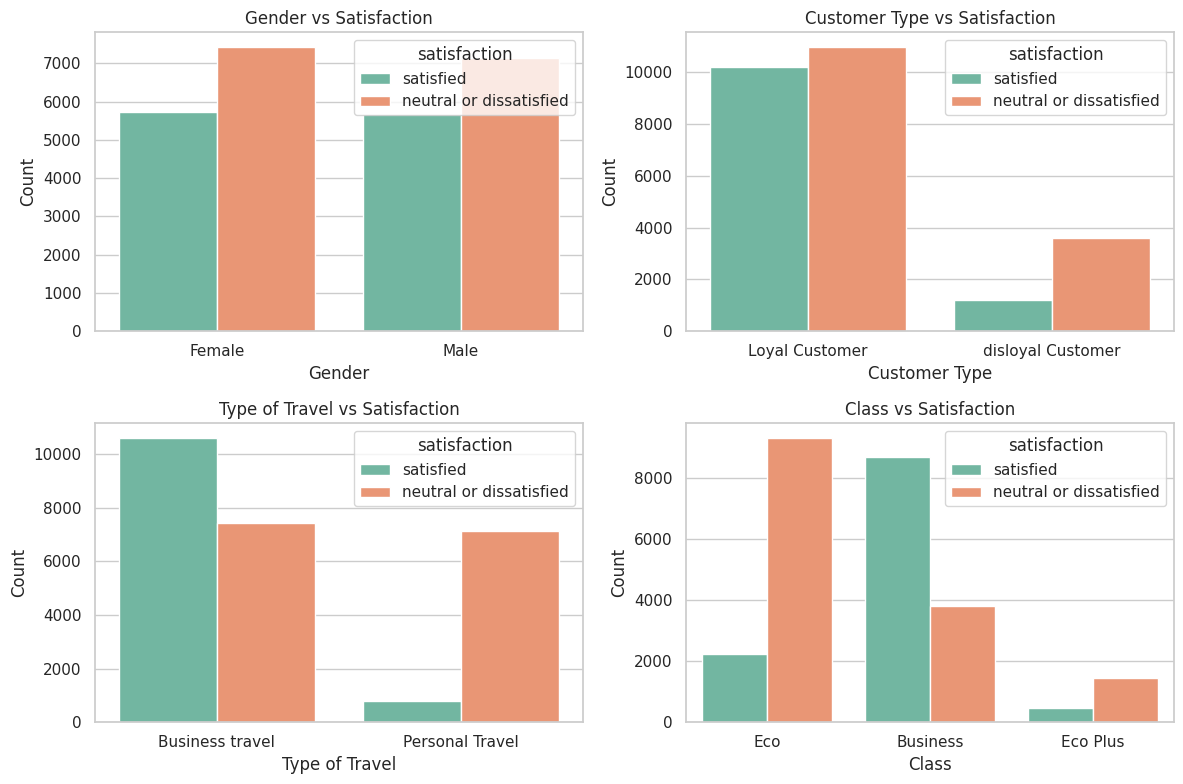

In [ ]:
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), categorical_cols):
    sns.countplot(data=df, x=col, hue='satisfaction', palette='Set2', ax=ax)
    ax.set_title(col + ' vs Satisfaction')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

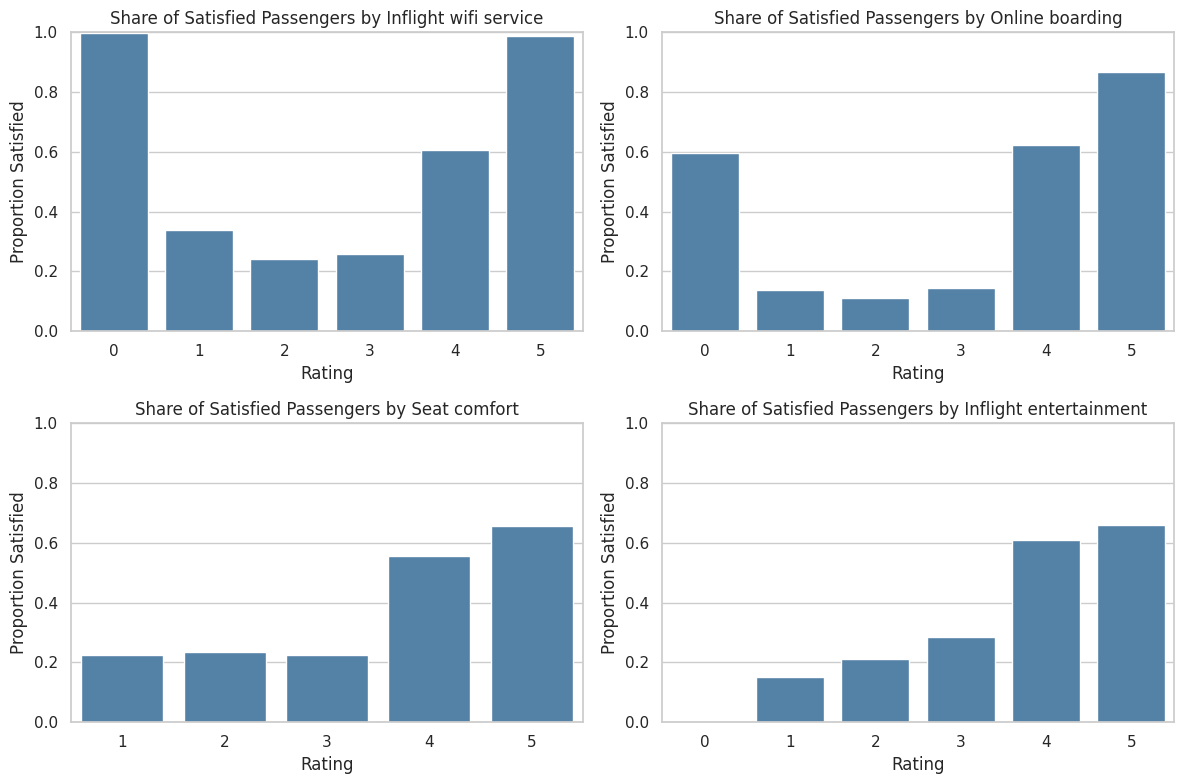

In [ ]:
rating_cols = ['Inflight wifi service', 'Online boarding', 'Seat comfort', 'Inflight entertainment']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), rating_cols):
    rate = df.groupby(col)['satisfaction'].apply(lambda s: (s == 'satisfied').mean())
    sns.barplot(x=rate.index, y=rate.values, ax=ax, color='steelblue')
    ax.set_title('Share of Satisfied Passengers by ' + col)
    ax.set_xlabel('Rating')
    ax.set_ylabel('Proportion Satisfied')
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**Data Preprocessing**

In [ ]:
data = df.drop(columns=['Unnamed: 0', 'id']).copy()

data['satisfaction'] = data['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})
data['Customer Type'] = data['Customer Type'].map({'disloyal Customer': 0, 'Loyal Customer': 1})
data['Type of Travel'] = data['Type of Travel'].map({'Personal Travel': 0, 'Business travel': 1})
data['Class'] = data['Class'].map({'Eco': 0, 'Eco Plus': 1, 'Business': 2})

print('Missing values after encoding:')
print(data.isnull().sum()[data.isnull().sum() > 0])

Missing values after encoding:
Arrival Delay in Minutes    83
dtype: int64


In [ ]:
X = data.drop(columns='satisfaction')
y = data['satisfaction']
class_names = ['Neutral/Dissatisfied', 'Satisfied']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_val = pd.DataFrame(imputer.transform(X_val), columns=X.columns, index=X_val.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)

print('Training set  :', X_train.shape)
print('Validation set:', X_val.shape)
print('Test set      :', X_test.shape)
print()
print('Missing values remaining:', int(X_train.isnull().sum().sum() + X_val.isnull().sum().sum() + X_test.isnull().sum().sum()))
print()
print('Positive class share (train / val / test):',
      round(y_train.mean(), 4), '/', round(y_val.mean(), 4), '/', round(y_test.mean(), 4))

Training set  : (15585, 22)
Validation set: (5195, 22)
Test set      : (5196, 22)

Missing values remaining: 0

Positive class share (train / val / test): 0.439 / 0.4389 / 0.439


In [ ]:
results = {}

def evaluate_model(name, model, X_eval, y_eval):
    pred = model.predict(X_eval)
    proba = model.predict_proba(X_eval)[:, 1]
    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_eval, pred),
        'Precision': precision_score(y_eval, pred),
        'Recall': recall_score(y_eval, pred),
        'F1-score': f1_score(y_eval, pred),
        'ROC-AUC': roc_auc_score(y_eval, proba)
    }
    results[name] = row
    print(pd.DataFrame([row]).round(4).to_string(index=False))
    print()
    print(classification_report(y_eval, pred, target_names=class_names, digits=4))
    ConfusionMatrixDisplay.from_predictions(y_eval, pred, display_labels=class_names, cmap='Blues')
    plt.title('Confusion Matrix - ' + name)
    plt.grid(False)
    plt.show()

def plot_importance(model, name, top=15):
    importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(top)
    print('Top 5 features:', list(importance.index[:5]))
    plt.figure(figsize=(8, 6))
    sns.barplot(x=importance.values, y=importance.index, color='steelblue')
    plt.title('Top ' + str(top) + ' Feature Importances - ' + name)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

**Baseline Model — Decision Tree**


        Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
Decision Tree    0.9282     0.9077  0.9312    0.9193   0.9285

                      precision    recall  f1-score   support

Neutral/Dissatisfied     0.9450    0.9259    0.9354      2915
           Satisfied     0.9077    0.9312    0.9193      2281

            accuracy                         0.9282      5196
           macro avg     0.9264    0.9285    0.9273      5196
        weighted avg     0.9286    0.9282    0.9283      5196



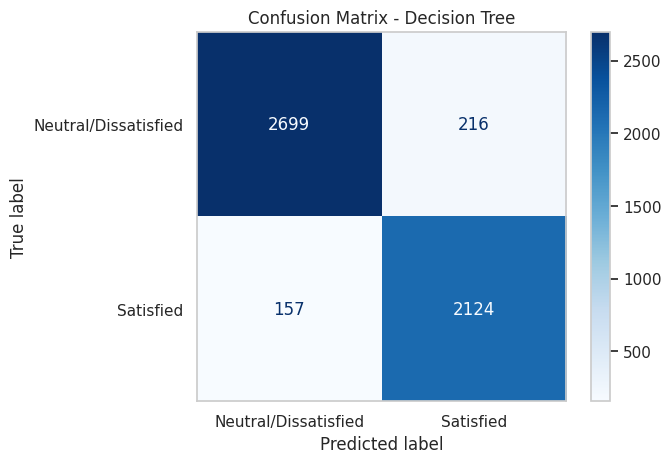

Training accuracy: 1.0


In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
evaluate_model('Decision Tree', dt, X_test, y_test)
print('Training accuracy:', round(dt.score(X_train, y_train), 4))

**Bagging**


  Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
Bagging    0.9542     0.9538  0.9413    0.9475   0.9913

                      precision    recall  f1-score   support

Neutral/Dissatisfied     0.9545    0.9643    0.9594      2915
           Satisfied     0.9538    0.9413    0.9475      2281

            accuracy                         0.9542      5196
           macro avg     0.9541    0.9528    0.9534      5196
        weighted avg     0.9542    0.9542    0.9542      5196



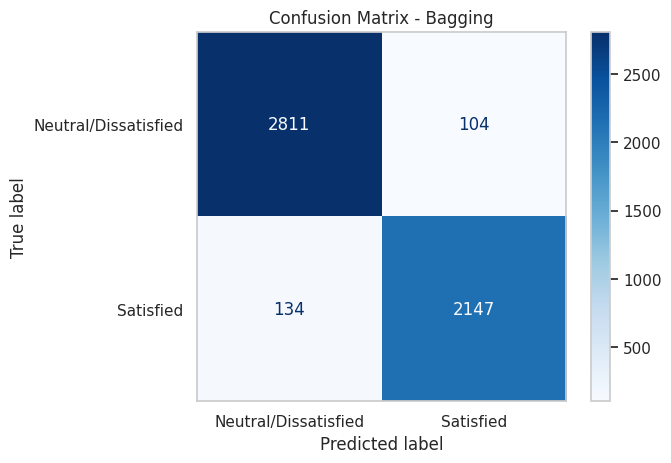

In [ ]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42, n_jobs=-1)
bag.fit(X_train, y_train)
evaluate_model('Bagging', bag, X_test, y_test)

In [ ]:
pd.DataFrame([results['Decision Tree'], results['Bagging']]).set_index('Model').round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Decision Tree,0.9282,0.9077,0.9312,0.9193,0.9285
Bagging,0.9542,0.9538,0.9413,0.9475,0.9913


**Boosting — AdaBoost**

   Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
AdaBoost    0.9238     0.9187  0.9066    0.9126   0.9741

                      precision    recall  f1-score   support

Neutral/Dissatisfied     0.9277    0.9372    0.9324      2915
           Satisfied     0.9187    0.9066    0.9126      2281

            accuracy                         0.9238      5196
           macro avg     0.9232    0.9219    0.9225      5196
        weighted avg     0.9237    0.9238    0.9237      5196



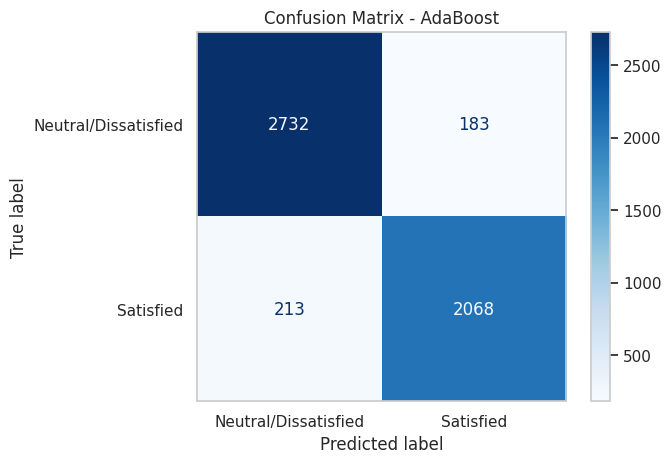

In [ ]:
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=200, learning_rate=0.5, random_state=42)
ada.fit(X_train, y_train)
evaluate_model('AdaBoost', ada, X_test, y_test)

In [ ]:
pd.DataFrame([results['Decision Tree'], results['Bagging'], results['AdaBoost']]).set_index('Model').round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Decision Tree,0.9282,0.9077,0.9312,0.9193,0.9285
Bagging,0.9542,0.9538,0.9413,0.9475,0.9913
AdaBoost,0.9238,0.9187,0.9066,0.9126,0.9741


**XGBoost**

  Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
XGBoost      0.96     0.9617  0.9465     0.954    0.994

                      precision    recall  f1-score   support

Neutral/Dissatisfied     0.9587    0.9705    0.9645      2915
           Satisfied     0.9617    0.9465    0.9540      2281

            accuracy                         0.9600      5196
           macro avg     0.9602    0.9585    0.9593      5196
        weighted avg     0.9600    0.9600    0.9599      5196



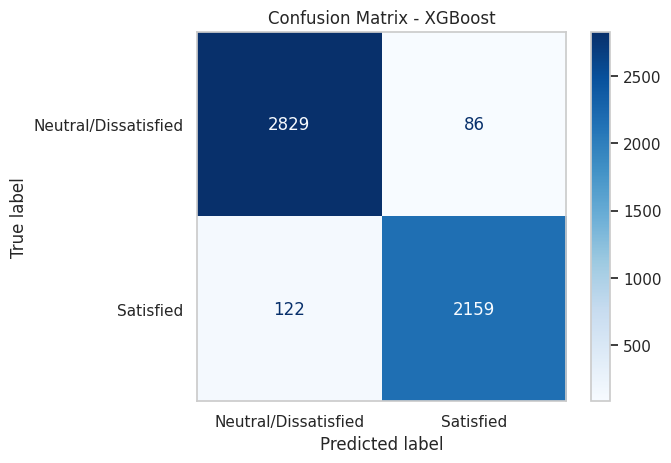

In [ ]:
xgb_params = dict(n_estimators=300, learning_rate=0.1, max_depth=6, subsample=0.8,
                  colsample_bytree=0.8, random_state=42, eval_metric='logloss')

xgb = XGBClassifier(**xgb_params)
xgb.fit(X_train, y_train)
evaluate_model('XGBoost', xgb, X_test, y_test)

Top 5 features: ['Type of Travel', 'Online boarding', 'Class', 'Inflight wifi service', 'Customer Type']


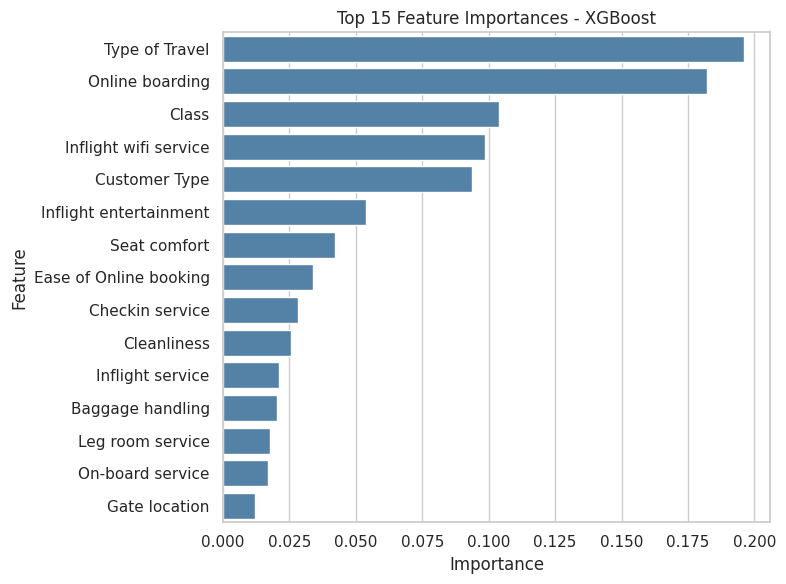

In [ ]:
plot_importance(xgb, 'XGBoost')

**LightGBM**


   Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
LightGBM    0.9629     0.9677   0.947    0.9572   0.9944

                      precision    recall  f1-score   support

Neutral/Dissatisfied     0.9592    0.9753    0.9672      2915
           Satisfied     0.9677    0.9470    0.9572      2281

            accuracy                         0.9629      5196
           macro avg     0.9635    0.9611    0.9622      5196
        weighted avg     0.9629    0.9629    0.9628      5196



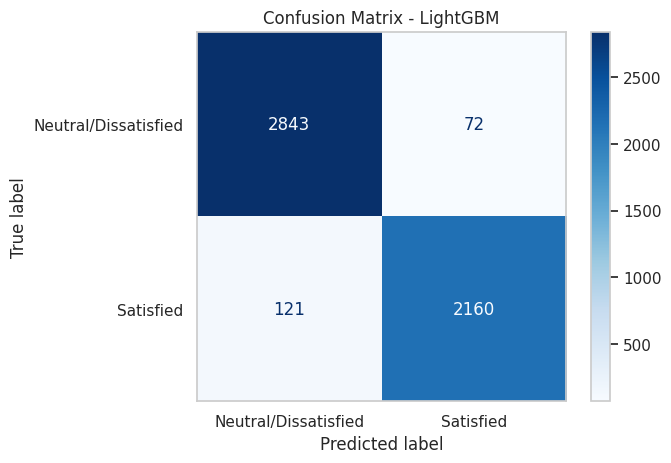

In [ ]:
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.1, num_leaves=31, subsample=0.8,
                      subsample_freq=1, colsample_bytree=0.8, importance_type='gain', random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
evaluate_model('LightGBM', lgbm, X_test, y_test)

Top 5 features: ['Online boarding', 'Inflight wifi service', 'Type of Travel', 'Class', 'Inflight entertainment']


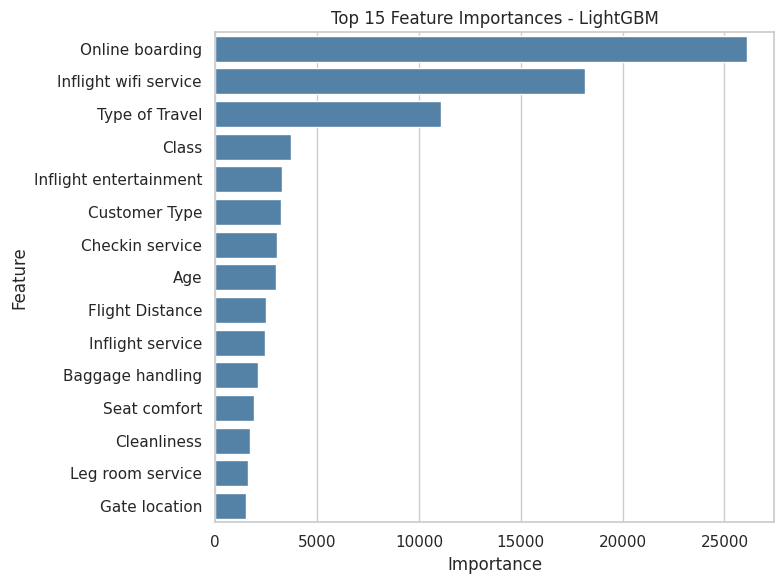

In [ ]:
plot_importance(lgbm, 'LightGBM')


**Model Comparison**

In [ ]:
model_order = ['Decision Tree', 'Bagging', 'AdaBoost', 'XGBoost', 'LightGBM']
comparison = pd.DataFrame([results[m] for m in model_order]).set_index('Model').round(4)
comparison

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Decision Tree,0.9282,0.9077,0.9312,0.9193,0.9285
Bagging,0.9542,0.9538,0.9413,0.9475,0.9913
AdaBoost,0.9238,0.9187,0.9066,0.9126,0.9741
XGBoost,0.9600,0.9617,0.9465,0.9540,0.9940
LightGBM,0.9629,0.9677,0.9470,0.9572,0.9944


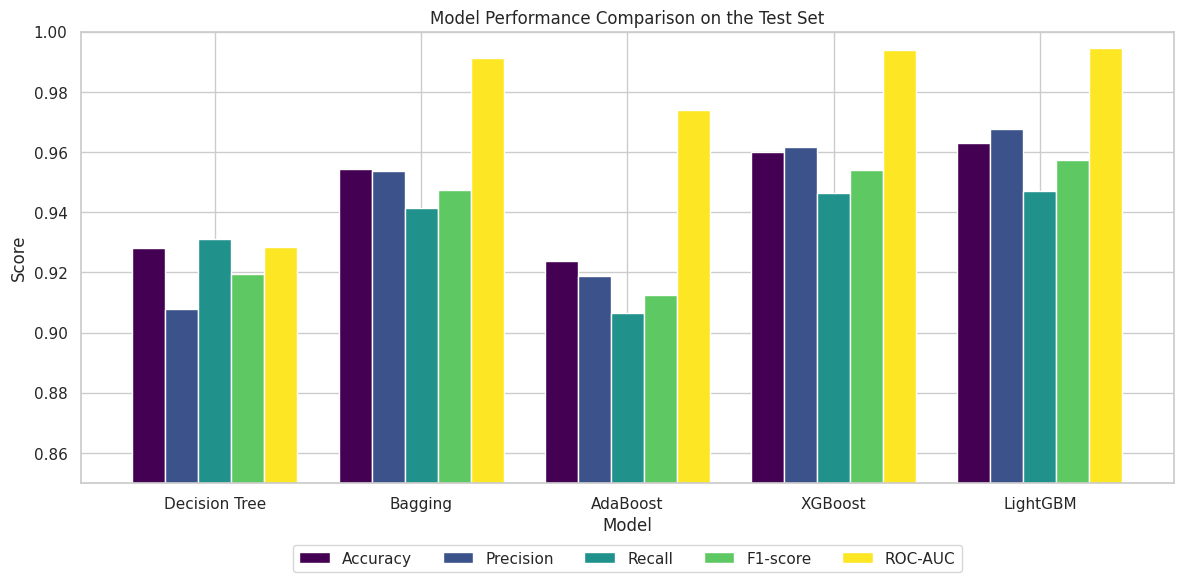

In [ ]:
comparison.plot(kind='bar', figsize=(12, 6), width=0.8, colormap='viridis')
plt.title('Model Performance Comparison on the Test Set')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=5)
plt.tight_layout()
plt.show()

**Bias–Variance Trade-off**


In [ ]:
depths = list(range(1, 26))
train_scores = []
val_scores = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    val_scores.append(tree.score(X_val, y_val))

depth_df = pd.DataFrame({'max_depth': depths, 'Train Accuracy': train_scores, 'Validation Accuracy': val_scores})
depth_df['Gap'] = depth_df['Train Accuracy'] - depth_df['Validation Accuracy']
best_depth = int(depth_df.loc[depth_df['Validation Accuracy'].idxmax(), 'max_depth'])

depth_df.round(4)

,max_depth,Train Accuracy,Validation Accuracy,Gap
0,1,0.7833,0.7790,0.0042
1,2,0.8612,0.8552,0.0060
2,3,0.8855,0.8772,0.0083
3,4,0.8894,0.8807,0.0088
4,5,0.9046,0.8962,0.0083
5,6,0.9192,0.9143,0.0049
6,7,0.9322,0.9245,0.0076
7,8,0.9412,0.9294,0.0119
8,9,0.9510,0.9363,0.0147
9,10,0.9576,0.9369,0.0207


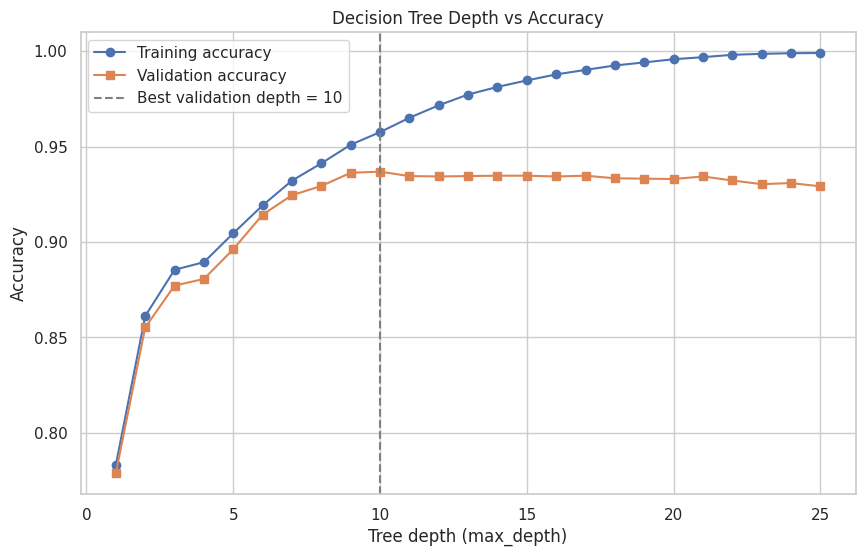

Best validation depth: 10
Training accuracy at best depth  : 0.9576
Validation accuracy at best depth: 0.9369
Validation accuracy at depth 1   : 0.779
Train-validation gap at depth 25 : 0.0699


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(depth_df['max_depth'], depth_df['Train Accuracy'], marker='o', label='Training accuracy')
plt.plot(depth_df['max_depth'], depth_df['Validation Accuracy'], marker='s', label='Validation accuracy')
plt.axvline(best_depth, color='gray', linestyle='--', label='Best validation depth = ' + str(best_depth))
plt.title('Decision Tree Depth vs Accuracy')
plt.xlabel('Tree depth (max_depth)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

best_row = depth_df[depth_df['max_depth'] == best_depth].iloc[0]
print('Best validation depth:', best_depth)
print('Training accuracy at best depth  :', round(best_row['Train Accuracy'], 4))
print('Validation accuracy at best depth:', round(best_row['Validation Accuracy'], 4))
print('Validation accuracy at depth 1   :', round(depth_df.loc[0, 'Validation Accuracy'], 4))
print('Train-validation gap at depth 25 :', round(depth_df.loc[24, 'Gap'], 4))

**Overfitting and Underfitting**

Three trees of different complexity are compared: a very shallow tree, the tree with the best validation depth, and a fully grown tree with no depth limit.

In [ ]:
cases = {'Very shallow tree (max_depth=1)': 1,
         'Best validation depth (max_depth=' + str(best_depth) + ')': best_depth,
         'Fully grown tree (max_depth=None)': None}

rows = []
for label, d in cases.items():
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc = tree.score(X_train, y_train)
    val_acc = tree.score(X_val, y_val)
    rows.append({'Model': label, 'Train Accuracy': train_acc, 'Validation Accuracy': val_acc, 'Gap': train_acc - val_acc})

fit_df = pd.DataFrame(rows).set_index('Model').round(4)
fit_df

,Train Accuracy,Validation Accuracy,Gap
Model,,,
Very shallow tree (max_depth=1),0.7833,0.7790,0.0042
Best validation depth (max_depth=10),0.9576,0.9369,0.0207
Fully grown tree (max_depth=None),1.0000,0.9311,0.0689


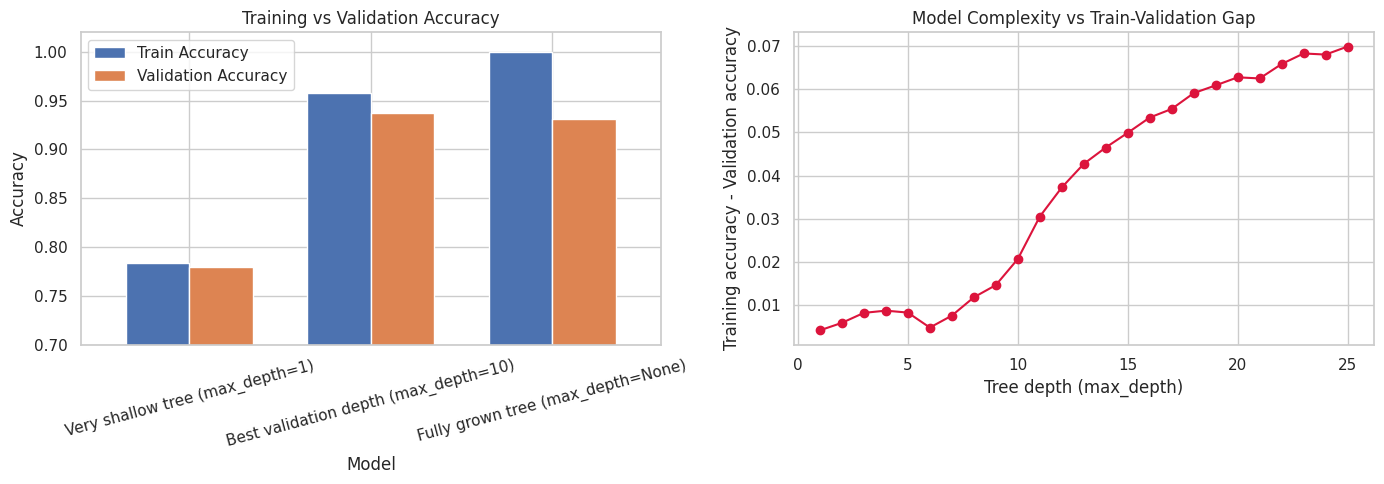

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fit_df[['Train Accuracy', 'Validation Accuracy']].plot(kind='bar', ax=axes[0], width=0.7)
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.7, 1.02)
axes[0].tick_params(axis='x', rotation=15)

axes[1].plot(depth_df['max_depth'], depth_df['Gap'], marker='o', color='crimson')
axes[1].set_title('Model Complexity vs Train-Validation Gap')
axes[1].set_xlabel('Tree depth (max_depth)')
axes[1].set_ylabel('Training accuracy - Validation accuracy')

plt.tight_layout()
plt.show()

**Observations**

| Model | Training accuracy | Validation accuracy | Situation |
|---|---|---|---|
| max_depth=1 | 0.7833 | 0.7790 | Underfitting: both scores are low and close together |
| max_depth=10 | 0.9576 | 0.9369 | Reasonable balance: highest validation accuracy, small gap |
| max_depth=None | 1.0000 | 0.9311 | Overfitting: perfect training score, lower validation score, gap of about 0.07 |

Underfitting shows up as low performance on both sets, whereas overfitting shows up as a high training score with a clearly lower validation score. The right-hand plot shows that the gap between the two scores increases with model complexity.

**L1 Regularization**

In [ ]:
def mean_leaf_weight(model):
    trees = model.get_booster().trees_to_dataframe()
    leaves = trees[trees['Feature'] == 'Leaf']
    return leaves['Gain'].abs().mean()

def run_regularization(param_name, values, fixed):
    rows = []
    for v in values:
        params = dict(xgb_params)
        params.update(fixed)
        params[param_name] = v
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        train_acc = model.score(X_train, y_train)
        val_acc = accuracy_score(y_val, val_pred)
        rows.append({
            param_name: v,
            'Train Accuracy': train_acc,
            'Validation Accuracy': val_acc,
            'Gap': train_acc - val_acc,
            'Validation F1': f1_score(y_val, val_pred),
            'Validation ROC-AUC': roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]),
            'Mean |Leaf Weight|': mean_leaf_weight(model)
        })
    return pd.DataFrame(rows)

In [ ]:
alpha_values = [0, 0.1, 1, 5, 10, 50]
l1_df = run_regularization('reg_alpha', alpha_values, {'reg_lambda': 1})
l1_df.round(4)

,reg_alpha,Train Accuracy,Validation Accuracy,Gap,Validation F1,Validation ROC-AUC,Mean |Leaf Weight|
0,0.0,0.9967,0.9565,0.0402,0.9499,0.9927,0.0452
1,0.1,0.9970,0.9563,0.0407,0.9497,0.9926,0.0425
2,1.0,0.9947,0.9540,0.0407,0.9470,0.9926,0.0279
3,5.0,0.9795,0.9544,0.0251,0.9475,0.9929,0.0148
4,10.0,0.9682,0.9546,0.0136,0.9477,0.9927,0.0129
5,50.0,0.9448,0.9397,0.0050,0.9311,0.9871,0.0117


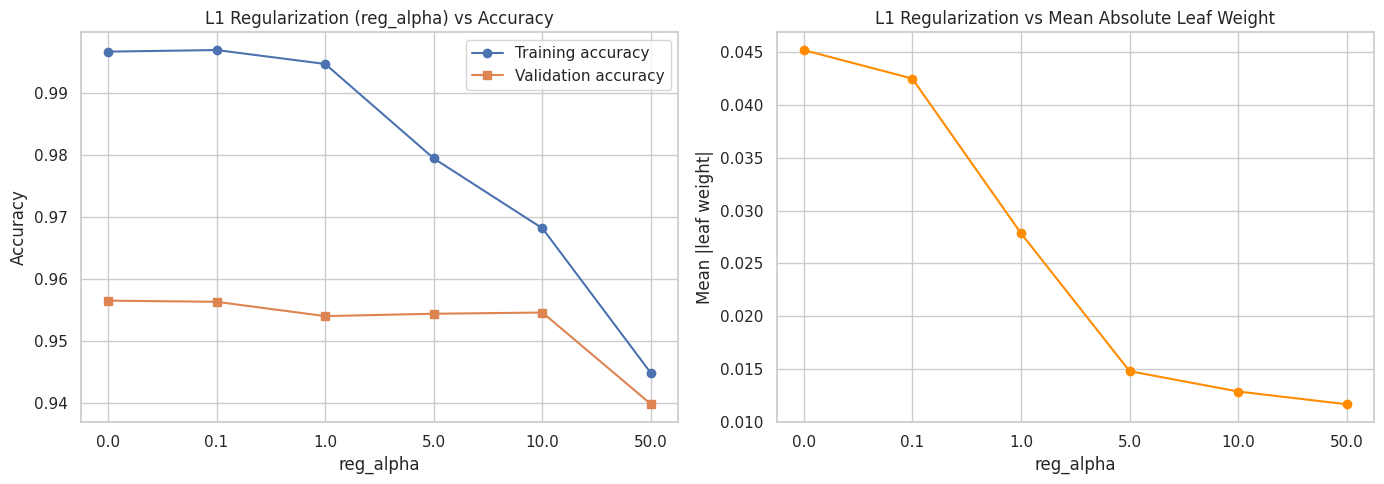

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
positions = range(len(l1_df))

axes[0].plot(positions, l1_df['Train Accuracy'], marker='o', label='Training accuracy')
axes[0].plot(positions, l1_df['Validation Accuracy'], marker='s', label='Validation accuracy')
axes[0].set_xticks(list(positions))
axes[0].set_xticklabels(l1_df['reg_alpha'])
axes[0].set_title('L1 Regularization (reg_alpha) vs Accuracy')
axes[0].set_xlabel('reg_alpha')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(positions, l1_df['Mean |Leaf Weight|'], marker='o', color='darkorange')
axes[1].set_xticks(list(positions))
axes[1].set_xticklabels(l1_df['reg_alpha'])
axes[1].set_title('L1 Regularization vs Mean Absolute Leaf Weight')
axes[1].set_xlabel('reg_alpha')
axes[1].set_ylabel('Mean |leaf weight|')

plt.tight_layout()
plt.show()

**L2 Regularization**

In [ ]:
lambda_values = [0, 1, 10, 50, 100, 500]
l2_df = run_regularization('reg_lambda', lambda_values, {'reg_alpha': 0})
l2_df.round(4)

,reg_lambda,Train Accuracy,Validation Accuracy,Gap,Validation F1,Validation ROC-AUC,Mean |Leaf Weight|
0,0,0.9985,0.9553,0.0431,0.9485,0.9926,0.0689
1,1,0.9967,0.9565,0.0402,0.9499,0.9927,0.0452
2,10,0.9872,0.9534,0.0338,0.9463,0.9926,0.0210
3,50,0.9720,0.9538,0.0182,0.9469,0.9925,0.0104
4,100,0.9655,0.9534,0.0121,0.9465,0.9921,0.0075
5,500,0.9498,0.9436,0.0062,0.9354,0.9889,0.0039


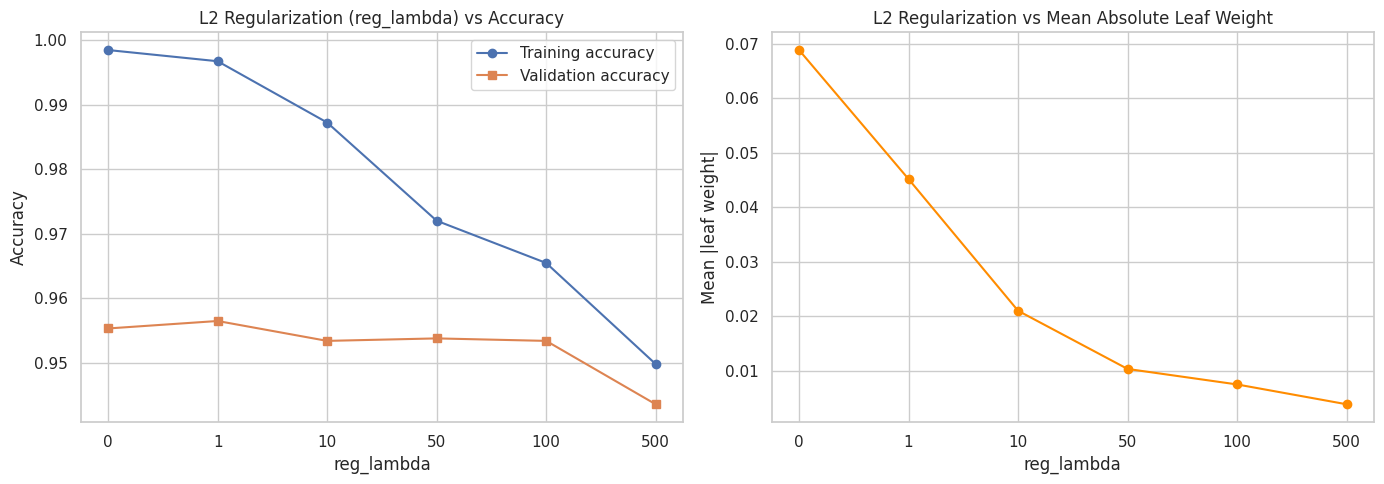

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
positions = range(len(l2_df))

axes[0].plot(positions, l2_df['Train Accuracy'], marker='o', label='Training accuracy')
axes[0].plot(positions, l2_df['Validation Accuracy'], marker='s', label='Validation accuracy')
axes[0].set_xticks(list(positions))
axes[0].set_xticklabels(l2_df['reg_lambda'])
axes[0].set_title('L2 Regularization (reg_lambda) vs Accuracy')
axes[0].set_xlabel('reg_lambda')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(positions, l2_df['Mean |Leaf Weight|'], marker='o', color='darkorange')
axes[1].set_xticks(list(positions))
axes[1].set_xticklabels(l2_df['reg_lambda'])
axes[1].set_title('L2 Regularization vs Mean Absolute Leaf Weight')
axes[1].set_xlabel('reg_lambda')
axes[1].set_ylabel('Mean |leaf weight|')

plt.tight_layout()
plt.show()

**L1 vs L2 Comparison**

In [ ]:
l1_table = l1_df.rename(columns={'reg_alpha': 'Value'}).assign(Type='L1 (reg_alpha)')
l2_table = l2_df.rename(columns={'reg_lambda': 'Value'}).assign(Type='L2 (reg_lambda)')

reg_table = pd.concat([l1_table, l2_table], ignore_index=True)
reg_table = reg_table[['Type', 'Value', 'Train Accuracy', 'Validation Accuracy', 'Gap', 'Validation F1', 'Validation ROC-AUC']]
reg_table.round(4)

,Type,Value,Train Accuracy,Validation Accuracy,Gap,Validation F1,Validation ROC-AUC
0,L1 (reg_alpha),0.0,0.9967,0.9565,0.0402,0.9499,0.9927
1,L1 (reg_alpha),0.1,0.9970,0.9563,0.0407,0.9497,0.9926
2,L1 (reg_alpha),1.0,0.9947,0.9540,0.0407,0.9470,0.9926
3,L1 (reg_alpha),5.0,0.9795,0.9544,0.0251,0.9475,0.9929
4,L1 (reg_alpha),10.0,0.9682,0.9546,0.0136,0.9477,0.9927
5,L1 (reg_alpha),50.0,0.9448,0.9397,0.0050,0.9311,0.9871
6,L2 (reg_lambda),0.0,0.9985,0.9553,0.0431,0.9485,0.9926
7,L2 (reg_lambda),1.0,0.9967,0.9565,0.0402,0.9499,0.9927
8,L2 (reg_lambda),10.0,0.9872,0.9534,0.0338,0.9463,0.9926
9,L2 (reg_lambda),50.0,0.9720,0.9538,0.0182,0.9469,0.9925


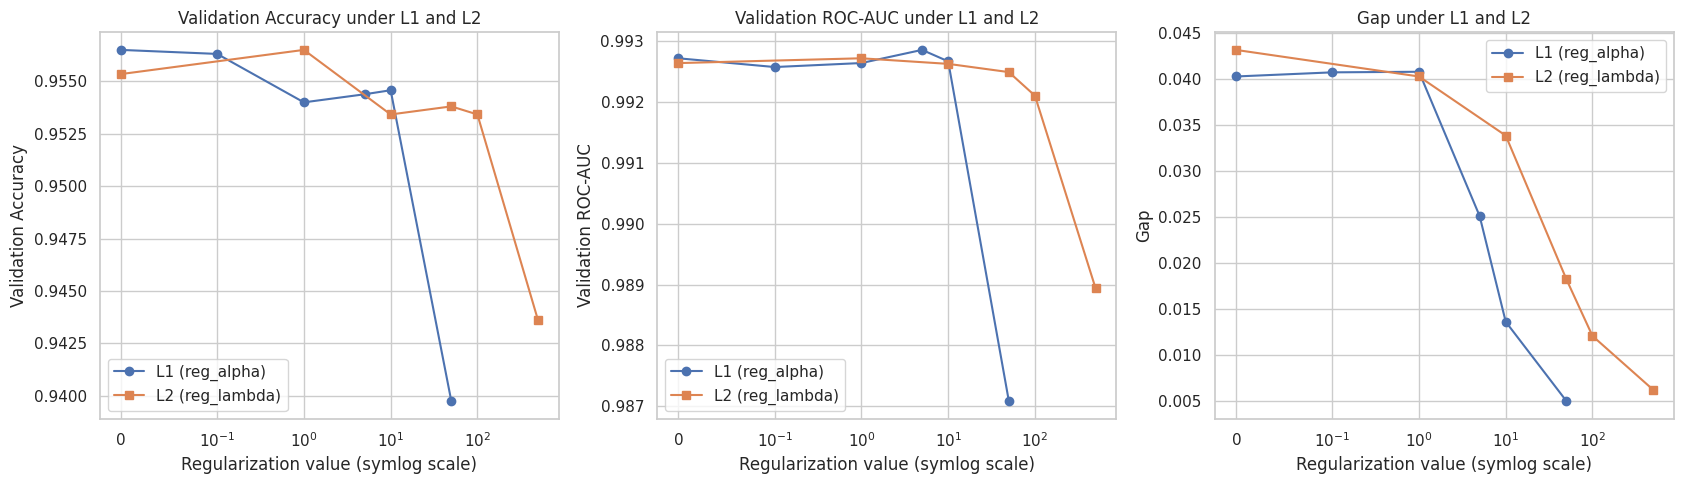

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, column in zip(axes, ['Validation Accuracy', 'Validation ROC-AUC', 'Gap']):
    ax.plot(l1_df['reg_alpha'], l1_df[column], marker='o', label='L1 (reg_alpha)')
    ax.plot(l2_df['reg_lambda'], l2_df[column], marker='s', label='L2 (reg_lambda)')
    ax.set_xscale('symlog', linthresh=0.1)
    ax.set_title(column + ' under L1 and L2')
    ax.set_xlabel('Regularization value (symlog scale)')
    ax.set_ylabel(column)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
def pick_strongest(table, column, tolerance=0.005):
    best_score = table['Validation Accuracy'].max()
    close = table[table['Validation Accuracy'] >= best_score - tolerance]
    return close[column].iloc[-1]

best_alpha = pick_strongest(l1_df, 'reg_alpha')
best_lambda = pick_strongest(l2_df, 'reg_lambda')

selected = pd.concat([
    l1_df[l1_df['reg_alpha'] == 0].iloc[[0]].assign(Setting='No L1 (reg_alpha=0)'),
    l1_df[l1_df['reg_alpha'] == best_alpha].assign(Setting='Selected L1 (reg_alpha=' + str(best_alpha) + ')'),
    l2_df[l2_df['reg_lambda'] == best_lambda].assign(Setting='Selected L2 (reg_lambda=' + str(best_lambda) + ')')
])

selected.set_index('Setting')[['Train Accuracy', 'Validation Accuracy', 'Gap', 'Validation F1', 'Validation ROC-AUC', 'Mean |Leaf Weight|']].round(4)

,Train Accuracy,Validation Accuracy,Gap,Validation F1,Validation ROC-AUC,Mean |Leaf Weight|
Setting,,,,,,
No L1 (reg_alpha=0),0.9967,0.9565,0.0402,0.9499,0.9927,0.0452
Selected L1 (reg_alpha=10.0),0.9682,0.9546,0.0136,0.9477,0.9927,0.0129
Selected L2 (reg_lambda=100),0.9655,0.9534,0.0121,0.9465,0.9921,0.0075


**Final Model Comparison**


In [ ]:
for name, extra in [('XGBoost + best L1', dict(reg_alpha=best_alpha, reg_lambda=1)),
                    ('XGBoost + best L2', dict(reg_alpha=0, reg_lambda=best_lambda)),
                    ('XGBoost + best L1 & L2', dict(reg_alpha=best_alpha, reg_lambda=best_lambda))]:
    params = dict(xgb_params)
    params.update(extra)
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    }

final_order = model_order + ['XGBoost + best L1', 'XGBoost + best L2', 'XGBoost + best L1 & L2']
final_df = pd.DataFrame([results[m] for m in final_order]).set_index('Model').round(4)
final_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Decision Tree,0.9282,0.9077,0.9312,0.9193,0.9285
Bagging,0.9542,0.9538,0.9413,0.9475,0.9913
AdaBoost,0.9238,0.9187,0.9066,0.9126,0.9741
XGBoost,0.9600,0.9617,0.9465,0.9540,0.9940
LightGBM,0.9629,0.9677,0.9470,0.9572,0.9944
XGBoost + best L1,0.9575,0.9602,0.9421,0.9511,0.9935
XGBoost + best L2,0.9567,0.9597,0.9408,0.9502,0.9932
XGBoost + best L1 & L2,0.9550,0.9579,0.9386,0.9482,0.9922


In [ ]:
print('Selected reg_alpha :', best_alpha)
print('Selected reg_lambda:', best_lambda)

Selected reg_alpha : 10.0
Selected reg_lambda: 100


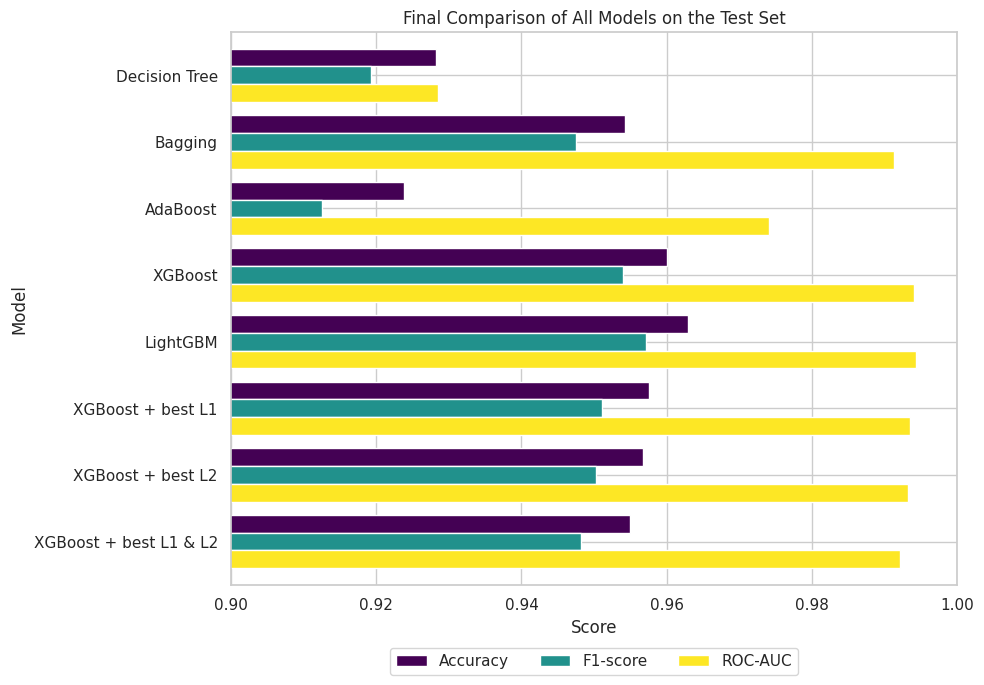

In [ ]:
final_df[['Accuracy', 'F1-score', 'ROC-AUC']].plot(kind='barh', figsize=(10, 7), width=0.8, colormap='viridis')
plt.title('Final Comparison of All Models on the Test Set')
plt.xlabel('Score')
plt.ylabel('Model')
plt.xlim(0.9, 1.0)
plt.gca().invert_yaxis()
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.tight_layout()
plt.show()

**Conclusion**

- **Bagging** reduces variance by combining many independently trained models built on bootstrap samples.
- **Boosting** builds models sequentially, with each new model focusing on the errors of the earlier ones.
- **XGBoost and LightGBM** are powerful gradient boosting methods that build trees step by step to reduce the loss.
- **Bias and variance** determine how well a model generalizes: too simple a model has high bias, too complex a model has high variance.
- **Overfitting and underfitting** can be identified by comparing training and validation performance.
- **L1 and L2 regularization** control model complexity by penalizing large leaf weights in the boosted trees.


**Findings from this practical**

- Bagging raised the test accuracy of the Decision Tree from 0.9282 to 0.9542 by averaging many trees.
- The gradient boosting models gave the highest scores in this run: LightGBM (accuracy 0.9629) and XGBoost (0.9600), while AdaBoost (0.9238) did not beat the single tree in accuracy.
- The depth experiment showed underfitting at `max_depth=1` (validation accuracy 0.7790), the best validation accuracy at `max_depth=10` (0.9369) and a widening train-validation gap for deeper trees (about 0.07 at depth 25).
- L1 and L2 regularization reduced the train-validation gap of XGBoost (from 0.0402 to 0.0136 and 0.0121 respectively) but did not improve the test accuracy here, so their value is in controlling complexity rather than guaranteeing a higher score.
- The results depend on one train/validation/test split and fixed hyperparameters; repeating the experiment with cross-validation would give a more reliable comparison.